### Prof. Alfio Ferrara

# Parlare con la macchina

##  Metodologie informatiche nelle discipline umanistiche
##### A.A. 2026/2027

---

Fin qui abbiamo visto come la macchina rappresenta l'informazione: bit, testi, numeri, immagini, documenti. Ora ci chiediamo come le si può *far fare* qualcosa. Per farlo abbiamo bisogno di un modo per parlarle.

In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Un compito per una tartaruga

Immaginiamo una macchina molto semplice: una **tartaruga** che si muove su un foglio, con una penna attaccata al corpo. Parte al centro, rivolta verso l'alto, con la penna abbassata. Non sa fare altro che eseguire, uno alla volta, i comandi che riceve:

| Comando | Cosa fa la tartaruga |
|---|---|
| `avanti N` | avanza di N passi, disegnando |
| `destra G` | ruota di G gradi in senso orario, restando ferma |

Il nostro compito: **farle disegnare un quadrato**. Dettiamo le istruzioni, nell'ordine in cui devono essere eseguite.

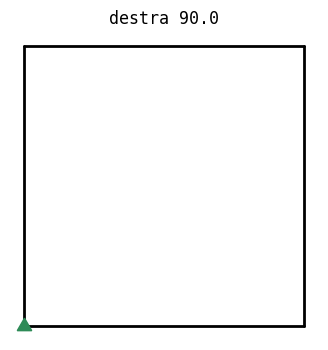

In [45]:
from nlp.toy_language import animate

program = """
avanti 100
destra 90
avanti 100
destra 90
avanti 100
destra 90
avanti 100
destra 90
"""

animate(program, delay=0.6);

## Un momento di riflessione

- La tartaruga ha eseguito le istruzioni senza sapere cosa sia un quadrato. Cosa sa, e cosa no?
- Cosa succede se cambiamo l'ordine delle istruzioni? E se ne togliamo una?
- Nella dettatura abbiamo dato per scontate cose che una persona capisce da sé (per esempio "gira di 90 gradi" verso quale lato?). Quali regole ha dovuto avere la tartaruga per non lasciare dubbi?
- Ricordate il gioco delle carte di L01: chi doveva decodificare il messaggio senza capirlo, applicando solo regole condivise. Cosa hanno in comune i due casi?

## Il programma è un testo

Quello che abbiamo dettato alla tartaruga è una sequenza di righe di testo. Per il computer, il nostro programma è una stringa come tutte le altre: la conservava in memoria come sequenza di caratteri, cioè di byte.

Guardiamolo per quello che è.

In [46]:
print(repr(program))
print()

line = "avanti 100"
for character in line:
    print(repr(character), format(ord(character), "08b"))
print()

print("Caratteri:", len(program))
print("Byte:", len(program.encode()))
print("Comandi e numeri:", len(program.split()))

'\navanti 100\ndestra 90\navanti 100\ndestra 90\navanti 100\ndestra 90\navanti 100\ndestra 90\n'

'a' 01100001
'v' 01110110
'a' 01100001
'n' 01101110
't' 01110100
'i' 01101001
' ' 00100000
'1' 00110001
'0' 00110000
'0' 00110000

Caratteri: 85
Byte: 85
Comandi e numeri: 16


## Lo stesso disegno, un altro testo

Scrivere quattro volte le stesse due righe è faticoso. Aggiungiamo alla lingua della tartaruga un comando che dice di **ripetere** un gruppo di istruzioni:

| Comando | Cosa fa la tartaruga |
|---|---|
| `ripeti N [ ... ]` | esegue N volte le istruzioni tra parentesi quadre |

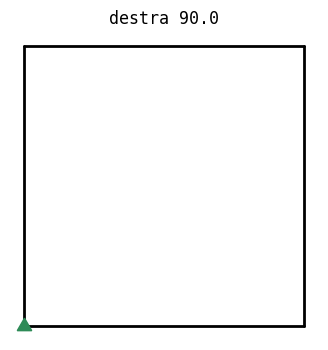

In [47]:
short_program = "ripeti 4 [ avanti 100 destra 90 ]"

print("Caratteri:", len(short_program))
print("Byte:", len(short_program.encode()))
animate(short_program, delay=0.6);

## Ora tocca a noi

Con lo stesso linguaggio possiamo scrivere altre figure. Alcuni comandi in più:

| Comando | Cosa fa la tartaruga |
|---|---|
| `sinistra G` | ruota di G gradi in senso antiorario |
| `indietro N` | arretra di N passi |
| `alza` / `abbassa` | solleva o abbassa la penna (senza penna si muove senza disegnare) |
| `colore C` | cambia colore: `rosso`, `blu`, `verde`, `giallo`, `arancione`, `viola`, `rosa`, `marrone`, `grigio`, `nero` |
| `spessore N` | cambia lo spessore del tratto |

Un testo che comincia con `#` (fino a fine riga) è un commento, e la tartaruga lo ignora.

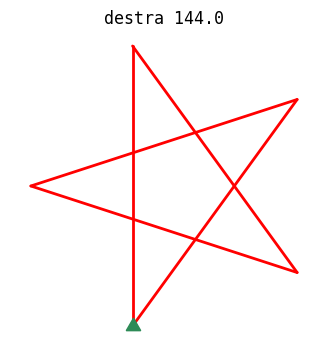

In [48]:
animate("""
colore rosso
ripeti 5 [ avanti 100 destra 144 ]
""", delay=0.3);

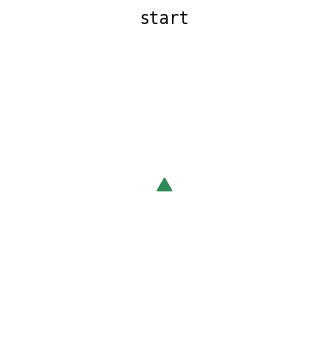

In [49]:
animate("""
# scrivete qui il vostro programma
""", delay=0.3);

## Un momento di riflessione

- Quando abbiamo scritto il programma, abbiamo scritto un testo. Cosa lo rende un *programma*, e non un semplice testo?
- Il quadrato lungo e il quadrato con `ripeti` hanno lunghezze diverse ma producono lo stesso disegno. Sono lo stesso programma? Cosa cambia per chi lo scrive, e cosa per chi lo esegue?
- Nel notebook di codifica abbiamo visto che gli stessi byte possono voler dire cose diverse a seconda di come vengono letti. Cosa deve fare la tartaruga per dare un significato a quei byte?
- Cosa succede se scriviamo un testo che la tartaruga non è in grado di leggere?

## Dentro l'interprete

Il programma che legge il nostro testo e muove la tartaruga si chiama **interprete**. Ha un compito preciso: partire da una stringa di caratteri e arrivare a un disegno. Lo fa in tre passaggi, che possiamo guardare uno alla volta.

**Primo passaggio: dividere il testo in pezzi.** L'interprete non ragiona sui singoli caratteri: prima separa il testo in parole, numeri e parentesi.

In [50]:
from nlp.toy_language import tokenize

tokens = tokenize(short_program)
print(short_program)
print(tokens)

ripeti 4 [ avanti 100 destra 90 ]
['ripeti', '4', '[', 'avanti', '100', 'destra', '90', ']']


**Secondo passaggio: riconoscere la struttura.** Una lista di pezzi non basta: bisogna capire quali comandi ci sono, con quali argomenti, e cosa sta dentro un `ripeti`. Lo vediamo su un programma con un `ripeti` dentro un altro.

In [51]:
from pprint import pprint
from nlp.toy_language import parse

nested_program = "ripeti 3 [ ripeti 4 [ avanti 20 destra 90 ] destra 120 ]"

print(nested_program)
print(tokenize(nested_program))
print()
pprint(parse(tokenize(nested_program)), width=50)

ripeti 3 [ ripeti 4 [ avanti 20 destra 90 ] destra 120 ]
['ripeti', '3', '[', 'ripeti', '4', '[', 'avanti', '20', 'destra', '90', ']', 'destra', '120', ']']

[('ripeti',
  3.0,
  [('ripeti',
    4.0,
    [('avanti', 20.0), ('destra', 90.0)]),
   ('destra', 120.0)])]


**Terzo passaggio: eseguire.** Ora l'interprete ha una lista di istruzioni precise. Le esegue una alla volta, e a ogni passo la tartaruga tiene traccia di dove si trova, verso dove guarda e se la penna è abbassata: è la sua *memoria*. Seguiamo il quadrato con `ripeti`.

In [52]:
from nlp.toy_language import Turtle, execute, flatten

tree = parse(tokenize(short_program))
turtle = Turtle()
print(f"{'istruzione':<16}{'x':>8}{'y':>8}{'direzione':>12}")
print(f"{'(inizio)':<16}{turtle.x:8.1f}{turtle.y:8.1f}{turtle.heading:12.1f}")
for instruction in flatten(tree):
    execute([instruction], turtle)
    label = " ".join(str(part) for part in instruction)
    print(f"{label:<16}{turtle.x:8.1f}{turtle.y:8.1f}{turtle.heading:12.1f}")

istruzione             x       y   direzione
(inizio)             0.0     0.0        90.0
avanti 100.0         0.0   100.0        90.0
destra 90.0          0.0   100.0         0.0
avanti 100.0       100.0   100.0         0.0
destra 90.0        100.0   100.0       -90.0
avanti 100.0       100.0     0.0       -90.0
destra 90.0        100.0     0.0      -180.0
avanti 100.0         0.0    -0.0      -180.0
destra 90.0          0.0    -0.0      -270.0


L'interprete è un programma come gli altri, scritto in Python. Il primo passaggio, per esempio, è una funzione di poche righe: possiamo leggerla.

In [53]:
import inspect

print(inspect.getsource(tokenize))

def tokenize(source: str) -> list:
    lines = [line.split("#")[0] for line in source.splitlines()]
    text = " ".join(lines).replace("[", " [ ").replace("]", " ] ")
    return text.split()



## Un momento di riflessione

- Dopo il primo passaggio, i pezzi sono ancora solo testo. Cosa aggiunge il secondo passaggio? Dove compare, per la prima volta, il significato di `ripeti`?
- Nella tabella del terzo passaggio, `x`, `y` e `direzione` cambiano a ogni istruzione. Dove sono conservati questi valori? Cosa succederebbe alla tartaruga se non li ricordasse?
- Il codice di `tokenize` è scritto in un linguaggio che voi non conoscete ancora. Cosa capite comunque, leggendolo?
- Chi ha deciso che `avanti` significa muoversi nella direzione in cui si guarda? Sta nel testo, nei byte, o nel programma che li legge?

## Quando il testo non torna

L'interprete accetta solo i testi che rispettano le regole del linguaggio. Proviamo a passargliene alcuni che non le rispettano. Per ogni programma ci chiediamo cosa risponderà l'interprete e perché; quando ne abbiamo discusso, premiamo invio per vedere la risposta.

In [54]:
from nlp.toy_language import show

wrong_programs = [
    ("avanti 100 salta 3",
     "Comando sconosciuto",
     "'salta' non fa parte del linguaggio: l'interprete conosce solo i comandi elencati nelle tabelle."),
    ("avanti 100 destra",
     "Argomento mancante",
     "'destra' vuole un numero di gradi, ma il testo finisce prima di darlo."),
    ("avanti cento",
     "Argomento del tipo sbagliato",
     "'avanti' vuole un numero scritto con le cifre: 'cento' per l'interprete è solo una parola."),
    ("colore fucsia",
     "Valore non previsto",
     "'colore' esiste, ma 'fucsia' non è tra i colori che l'interprete conosce."),
    ("ripeti 4 [ avanti 100 destra 90",
     "Parentesi non chiusa",
     "Ogni '[' deve avere la sua ']': qui il testo finisce con il gruppo ancora aperto."),
    ("avanti 100 ]",
     "Parentesi in più",
     "C'è una ']' che chiude un gruppo mai aperto."),
]

for wrong_program, error_type, reason in wrong_programs:
    print("Programma:", wrong_program)
    print("Cosa risponderà l'interprete?")
    input("Invio per vedere la risposta")
    print()
    print("Tipo di errore:", error_type)
    print("Perché:", reason)
    print("Risposta dell'interprete: ", end="")
    show(wrong_program)
    print("\n" + "-" * 60 + "\n")

Programma: avanti 100 salta 3
Cosa risponderà l'interprete?

Tipo di errore: Comando sconosciuto
Perché: 'salta' non fa parte del linguaggio: l'interprete conosce solo i comandi elencati nelle tabelle.
Risposta dell'interprete: Errore: comando sconosciuto: 'salta'

------------------------------------------------------------

Programma: avanti 100 destra
Cosa risponderà l'interprete?

Tipo di errore: Argomento mancante
Perché: 'destra' vuole un numero di gradi, ma il testo finisce prima di darlo.
Risposta dell'interprete: Errore: 'destra' richiede un argomento

------------------------------------------------------------

Programma: avanti cento
Cosa risponderà l'interprete?

Tipo di errore: Argomento del tipo sbagliato
Perché: 'avanti' vuole un numero scritto con le cifre: 'cento' per l'interprete è solo una parola.
Risposta dell'interprete: Errore: 'avanti' richiede un numero, non 'cento'

------------------------------------------------------------

Programma: colore fucsia
Cosa ris

Sono tutti errori di *forma*: il testo non rispetta le regole del linguaggio, e l'interprete se ne accorge prima di far muovere la tartaruga. Ma un testo può essere perfettamente valido e non fare quello che volevamo. Proviamo a disegnare di nuovo il quadrato, con un piccolo errore.

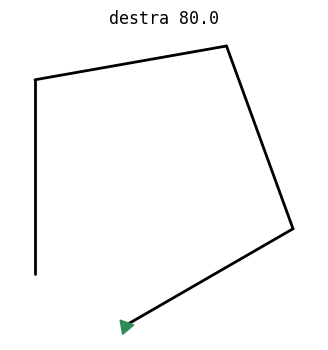

In [55]:
animate("ripeti 4 [ avanti 100 destra 80 ]", delay=0.6);

## Un momento di riflessione

- Nel primo gruppo di casi l'interprete si è fermato e ha spiegato cosa non andava. Nel quadrato sbagliato non ha protestato. Perché?
- Chi si accorge che il quadrato non si chiude? Come potrebbe accorgersene un programma, e non solo una persona?
- I messaggi di errore hanno richiesto a chi ha scritto l'interprete di prevedere in anticipo i modi in cui un testo può essere sbagliato. Cosa succede se ne dimentica uno?
- Un linguaggio è definito da ciò che l'interprete accetta e da ciò che fa. Se cambiassimo l'interprete, lo stesso testo potrebbe significare altro?

## E Python?

La tartaruga ha un suo linguaggio e un suo interprete. Python funziona allo stesso modo: è un linguaggio, e da qualche parte c'è un programma che lo interpreta. Cerchiamolo.

In [56]:
import sys

print(sys.executable)
print(sys.version)

/Users/Flint/.pyenv/versions/nlp/bin/python
3.10.4 (main, Dec 20 2024, 12:52:40) [Clang 16.0.0 (clang-1600.0.26.6)]


Quel file è un programma come gli altri: legge testo scritto in Python e lo esegue. Vediamo se anche lui, per farlo, passa per i nostri stessi passaggi. Prendiamo un ciclo Python che ripete quattro volte la stessa istruzione, l'equivalente del nostro `ripeti 4 [ ... ]`.

In [57]:
import ast
import io
import tokenize

python_program = """for i in range(4):
    print(i)
"""

print("Passaggio 1: i pezzi")
for token in tokenize.generate_tokens(io.StringIO(python_program).readline):
    if token.string.strip():
        print(f"  {tokenize.tok_name[token.type]:<8}{token.string!r}")

print()
print("Passaggio 2: la struttura")
print(ast.dump(ast.parse(python_program), indent=2))

Passaggio 1: i pezzi
  NAME    'for'
  NAME    'i'
  NAME    'in'
  NAME    'range'
  OP      '('
  NUMBER  '4'
  OP      ')'
  OP      ':'
  NAME    'print'
  OP      '('
  NAME    'i'
  OP      ')'

Passaggio 2: la struttura
Module(
  body=[
    For(
      target=Name(id='i', ctx=Store()),
      iter=Call(
        func=Name(id='range', ctx=Load()),
        args=[
          Constant(value=4)],
        keywords=[]),
      body=[
        Expr(
          value=Call(
            func=Name(id='print', ctx=Load()),
            args=[
              Name(id='i', ctx=Load())],
            keywords=[]))],
      orelse=[])],
  type_ignores=[])


## Lo stesso interprete, posti diversi

Il codice Python si può scrivere e far eseguire in modi molto diversi: in un terminale, riga per riga (il *REPL*, da *read, evaluate, print, loop*); in un file di testo lanciato da terminale (uno *script*); in un editor come VS Code; in un notebook come questo. In tutti i casi, dietro c'è lo stesso interprete. Lo dimostriamo lanciandolo dal notebook, come faremmo da un terminale.

In [58]:
import subprocess
import tempfile
from pathlib import Path

def run_python(*arguments):
    result = subprocess.run([sys.executable, *arguments], capture_output=True, text=True)
    return result.stdout + result.stderr

print("Versione:", run_python("--version").strip())
print("Una riga:", run_python("-c", "print(2 + 3)").strip())

script = Path(tempfile.gettempdir()) / "hello.py"
script.write_text("for i in range(3):\n    print('ciao', i)\n")
print(f"Script {script.name}:")
print(run_python(str(script)))

Versione: Python 3.10.4
Una riga: 5
Script hello.py:
ciao 0
ciao 1
ciao 2



## Un momento di riflessione

- Il nostro interprete e quello di Python passano per fasi simili. Cosa c'è di uguale, e cosa di diverso, tra la lista di pezzi della tartaruga e quella di Python?
- L'albero di Python per il ciclo `for` è molto più ricco di quello del nostro `ripeti`. Cosa può fare Python che la tartaruga non può?
- Se Python è un programma, chi lo ha scritto? In che linguaggio? E l'interprete di *quel* linguaggio?
- Terminale, script, editor e notebook eseguono lo stesso interprete. Perché allora esistono così tanti ambienti diversi? Cosa cambia per chi programma?